# Knowledge Discovery in Databases (KDD) Project: Heart Disease Classification
**Project Objective:** Applying the complete KDD process to extract valid, novel, potentially useful, and ultimately understandable patterns from clinical data, enabling the classification of patients into healthy or high-risk categories using a Random Forest Classifier.

## Phase 1: Data Selection
In this initial phase, we target the data necessary for our analytical goals. We isolate the clinical attributes from the UCI Heart Disease repository, establishing our target dataset.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Loading .csv dataset
try:
    df = pd.read_csv('./heart.csv')
    print("Target dataset selected and loaded successfully.")

    #df.shape shows rows and columns. So df.shape[0] shows the number of rows amd df[1] shows the number of the colomns
    
    print(f"Dataset dimensions: {df.shape[0]} samples and {df.shape[1]} attributes.")
except FileNotFoundError:
    print("Error: The file was not found. Check the directory.")

# Showing the first 15 rows of the dataset.
df.head(15)

Target dataset selected and loaded successfully.
Dataset dimensions: 1025 samples and 14 attributes.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [48]:
#Checking the distribution of the target variable

target_1 = df[df["target"]== 1]
target_0 = df[df["target"]== 0]

print(f"Number of patients with heart disease: {target_1.shape[0]}")
print(f"Number of healty patients: {target_0.shape[0]}")

check = target_1.shape[0] + target_0.shape[0]
print(f"Total number of patients: {check}")

Number of patients with heart disease: 526
Number of healty patients: 499
Total number of patients: 1025


## Phase 2: Data Pre-processing
This stage focuses on data cleaning. We evaluate data quality by checking for missing entries, identifying anomalies, and reviewing attribute distributions to establish a reliable baseline.

Analysis of missing values per attribute:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


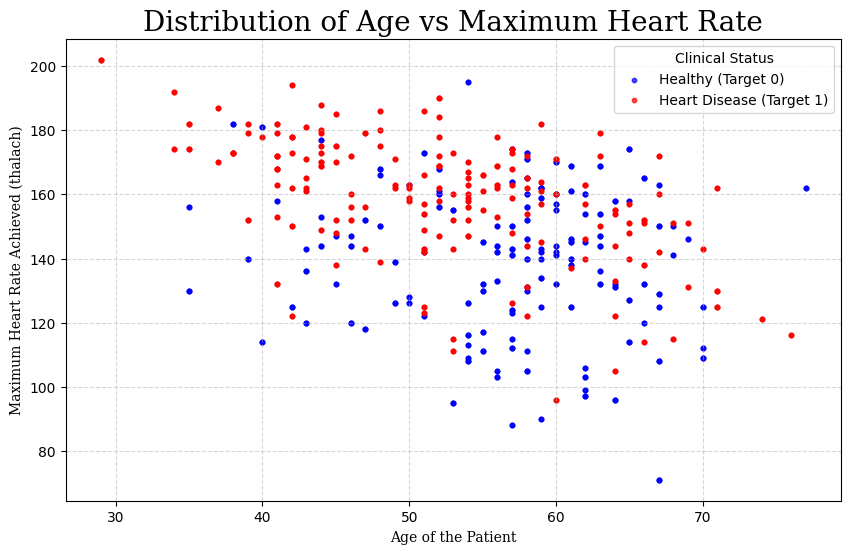

In [49]:
#Checking missing value per attribute
print("Analysis of missing values per attribute:")
print(df.isnull().sum()) #Sum of missing Attributes

# Separating the records for the binary classification
healty = df[df['target'] == 0]
sick = df[df['target'] == 1]

# Scatterplot construction using the Matplotlib interface
plt.figure(figsize=(10, 6)) #Width and Height in Inches
plt.scatter(healty['age'], healty['thalach'], color='blue', alpha=0.7, s=10, label='Healthy (Target 0)') #alpha sets the opacity for overlapping points. s is the size of the point.
plt.scatter(sick['age'], sick['thalach'], color='red', alpha=0.7, s=10, label='Heart Disease (Target 1)')

# Graphic configuration
plt.title("Distribution of Age vs Maximum Heart Rate", fontsize=20, fontfamily='serif')
plt.xlabel("Age of the Patient", fontfamily='serif')
plt.ylabel("Maximum Heart Rate Achieved (thalach)", fontfamily='serif')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Clinical Status') #loc="best" to insert the legend where we have minimum points density.
plt.show()

## Phase 3: Data Transformation
Data is transformed into forms appropriate for the data mining algorithm. In this project, transformation involves:
1. One-Hot Encoding to convert nominal categorical variables into separate binary dimensions.
2. Partitioning the data into Training (80%) and Testing (20%) sets to ensure rigorous evaluation.
3. Z-score Standardization applied exclusively to continuous numerical features to equalize variable scales.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# 1. One-Hot Coding Transformation selecting columns
columns = ['cp', 'restecg', 'slope', 'thal']

df_transformed = pd.get_dummies(df, columns=columns)  #talking about drop_first=True

# 2. Dividing indipendent variables (X) from traget variable (y)
X = df_transformed.drop('target', axis=1) #axis=1 to drop the column, axis=0 to drop the row
y = df_transformed['target']

# 3. Dividing Dataset in TrainSet and TestSet
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

# Creating copies to avoid conflicts with the original dataset
X_train = X_train.copy()
X_test = X_test.copy() 


# 4. Numeric Metrics. Standard Scaler is very useful not to give more meaning to a variable that has a higher value
numeric_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
global_scaler = StandardScaler()

# Calculation of parameters on the train set and subsequent application on the train and test sets
X_train[numeric_columns] = global_scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = global_scaler.transform(X_test[numeric_columns])

print(f"Transformation complete.")

Transformation complete.


In [51]:
df_transformed.head(10)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,...,False,True,False,False,False,True,False,False,False,True
1,53,1,140,203,1,155,1,3.1,0,0,...,True,False,False,True,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0,...,False,True,False,True,False,False,False,False,False,True
3,61,1,148,203,0,161,0,0.0,1,0,...,False,True,False,False,False,True,False,False,False,True
4,62,0,138,294,1,106,0,1.9,3,0,...,False,True,False,False,True,False,False,False,True,False
5,58,0,100,248,0,122,0,1.0,0,1,...,True,False,False,False,True,False,False,False,True,False
6,58,1,114,318,0,140,0,4.4,3,0,...,False,False,True,True,False,False,False,True,False,False
7,55,1,160,289,0,145,1,0.8,1,0,...,True,False,False,False,True,False,False,False,False,True
8,46,1,120,249,0,144,0,0.8,0,0,...,True,False,False,False,False,True,False,False,False,True
9,54,1,122,286,0,116,1,3.2,2,0,...,True,False,False,False,True,False,False,False,True,False


## Phase 4: Data Mining
The data mining phase applies algorithmic techniques to extract patterns. We implement a Random Forest Classifier, an ensemble method that trains multiple independent decision trees and aggregates their predictions. This approach typically enhances generalization performance and increases robustness against overfitting. We restrict the maximum depth (`max_depth=4`) to maintain structural control.

In [52]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
# n_estimators=100 defines the number of independent decision trees to train
# max_depth=4 limits the depth of each tree to avoid overfitting
# class_weight='balanced' handles any imbalances between classes in the clinical data
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42, 
    class_weight='balanced', 
    max_depth=4
)

# Running the training process on ​​the transformed subset
rf_model.fit(X_train, y_train)

# Generating predictions on the test set
y_pred = rf_model.predict(X_test)

print("Data mining execution successful. Random Forest patterns extracted.")

Data mining execution successful. Random Forest patterns extracted.


## Phase 5: Evaluation and Interpretation
Extracted patterns are evaluated through mathematical performance metrics. In this medical context, the primary focus remains on minimizing False Negatives by optimizing the **Recall (Sensitivity)** score. To interpret the ensemble model, we compute and visualize the Feature Importance ranking, showing which clinical attributes contributed most to the discovered knowledge.

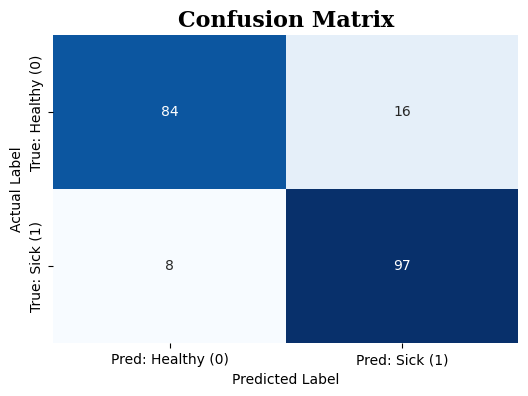

MODEL EVALUATION METRICS:

Overall Accuracy:  88.2927%
Precision:         85.8407%
Recall:            92.3810%
F1-Score:          88.9908%


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1. Calculation and graphical visualization of the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', cbar=False, 
            xticklabels=['Pred: Healthy (0)', 'Pred: Sick (1)'], 
            yticklabels=['True: Healthy (0)', 'True: Sick (1)'])
plt.title('Confusion Matrix', fontweight='bold', fontfamily='serif', fontsize=16)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 2. Calculation of the core evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 3. Analytical report printing
print("MODEL EVALUATION METRICS:")
print("")
print(f"Overall Accuracy:  {accuracy*100:.4f}%")
print(f"Precision:         {precision*100:.4f}%")
print(f"Recall:            {recall*100:.4f}%")
print(f"F1-Score:          {f1*100:.4f}%")

## Phase 6: Use of Discovered Knowledge
The final phase of the KDD process involves deploying the validated knowledge. We execute the Clinical Decision Support System (DSS) pipeline. The operational architecture implements a strict Data Validation layer to inspect input anomalies and prevent out-of-distribution processing before querying the Random Forest model.

In [56]:
import pandas as pd

# 1. Define the clinical parameters for the profile of the new subject
'''new_patient = {
    'age': 70,
    'sex': 0,
    'cp': 2,
    'trestbps': 200,
    'chol': 290,
    'fbs': 1,
    'restecg': 1,
    'thalach': 70,
    'exang': 1,
    'oldpeak': 0.5,
    'slope': 2,
    'ca': 0,
    'thal': 2
}'''

new_patient = {
    'age': 29, 'sex': 1, 'cp': 0, 'trestbps': 120, 'chol': 180,
    'fbs': 1, 'restecg': 2, 'thalach': 120, 'exang': 1, 
    'oldpeak': 3, 'slope': 0, 'ca': 2, 'thal': 1
}

print("=" * 60)
print("CLINICAL DECISION SUPPORT SYSTEM (DSS) ASSESSMENT")
print("=" * 60)

# 2. Data Validation Layer
# Verifies the biological plausibility of the inputs before predictive processing
error_messages = []

# Verify continuous physiological bounds based on the clinical training domain
if not (15 <= new_patient['age'] <= 110): error_messages.append("- Age out of biological bounds.")
if not (80 <= new_patient['trestbps'] <= 250): error_messages.append("- Blood pressure out of bounds.")
if not (100 <= new_patient['chol'] <= 600): error_messages.append("- Cholesterol strictly out of biological bounds.")
if not (40 <= new_patient['thalach'] <= 210): error_messages.append("- Maximum heart rate out of bounds.")

# Verify boolean and constrained categorical variables
if new_patient['ca'] not in [0,1,2,3]: error_messages.append("- Number of major vessels must be 0,1,2,3 ")
if new_patient['fbs'] not in [0, 1]: error_messages.append("- Fasting Blood Sugar (fbs) must be 0 or 1.")
if new_patient['exang'] not in [0, 1]: error_messages.append("- Exercise Induced Angina (exang) must be 0 or 1.")

# Evaluate validation results
if len(error_messages) > 0:
    print("INVALID INPUT DATA DETECTED.")
    print("The prediction was suspended due to the following anomalies:")
    for msg in error_messages:
        print(msg)
    print("Action Required: Check data entry for typos and resubmit.")
    print("-" * 60)

else:
    # 3. Transform the validated data into a structured DataFrame
    df_new = pd.DataFrame([new_patient])

    # 4. Align nominal categorical variables via One-Hot Encoding
    df_new = pd.get_dummies(df_new, columns=['cp', 'restecg', 'slope', 'thal'])
    #Reindexing to ensure the new data has the same structure as the training data, filling missing columns with 0.
    df_new = df_new.reindex(columns=X_train.columns, fill_value=0) 
    
    # 5. Normalize continuous variables using the scaler fitted during the training stage
    numeric_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
    df_new[numeric_columns] = global_scaler.transform(df_new[numeric_columns])

    # 6. Calculate risk probability using the trained classifier model
    risk_probability = rf_model.predict_proba(df_new)[0][1] 

    # 7. Structured output of the clinical classification
    if risk_probability >= 0.5:
        print(f"Result: HIGH RISK - Probability of heart disease: {risk_probability*100:.1f}%.")
        print("**Action Required**: Immediate scheduling of advanced cardiological screening.")
    else:
        print(f"Result: LOW RISK - Probability of heart disease: {risk_probability*100:.1f}%.")
        print("Action Required: Standard preventative check-up in 12 months.")

CLINICAL DECISION SUPPORT SYSTEM (DSS) ASSESSMENT
Result: LOW RISK - Probability of heart disease: 12.3%.
Action Required: Standard preventative check-up in 12 months.
